In [ ]:
#--------------------------Imports-------------------------------------#
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, make_scorer
from sklearn.preprocessing import StandardScaler
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import sys
sys.path.append("eval.py") 
from eval import notation
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

## Préparation des données:

In [ ]:
# importation des données
data_1 = pd.read_csv("./data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
data_2 = pd.read_csv("./data/2023-02-12.csv")

data_1.columns = data_1.columns.str.replace(" ", "").str.lower()
data_2.columns = data_2.columns.str.replace(" ", "").str.lower()

# on garde que les colonnes communes
common_columns = list(set(data_1.columns) & set(data_2.columns))

data_1 = data_1[common_columns]
data_2 = data_2[common_columns]

# on concatène les deux datasets
concatenated_data = pd.concat([data_1, data_2], ignore_index=True)
concatenated_data["label_ml"] = (concatenated_data["label"] != "BENIGN").astype(int)
concatenated_data["label_dl"]  = concatenated_data["label"]
concatenated_data = concatenated_data.drop(columns=["label"])

concatenated_data.replace([np.inf, -np.inf], np.nan, inplace=True)
concatenated_data.dropna(inplace=True)
concatenated_data = concatenated_data.sort_values(by="label_dl")

label_mapping = {
    'DDoS': 'ddos',
    'ddospot': 'ddos',
    'cowrie': 'SSH',
    'log4pot': 'SSH'
}

# Appliquer le mappage aux labels
concatenated_data['label_dl'] = concatenated_data['label_dl'].map(label_mapping).fillna(concatenated_data['label_dl'])

## Phase 1 : Détection d'Attaques avec Random Forest

c:\Users\ibrah\Desktop\IDIA-5A\PRED\PRED\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters (Random Search): {'n_estimators': np.int64(100), 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_depth': np.int64(5), 'criterion': 'gini', 'class_weight': 'balanced'}
Best Score (Random Search): 0.9989467173589286
Random Forest Performance (Optimized Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19526
           1       1.00      1.00      1.00     40851

    accuracy                           1.00     60377
   macro avg       1.00      1.00      1.00     60377
weighted avg       1.00      1.00      1.00     60377



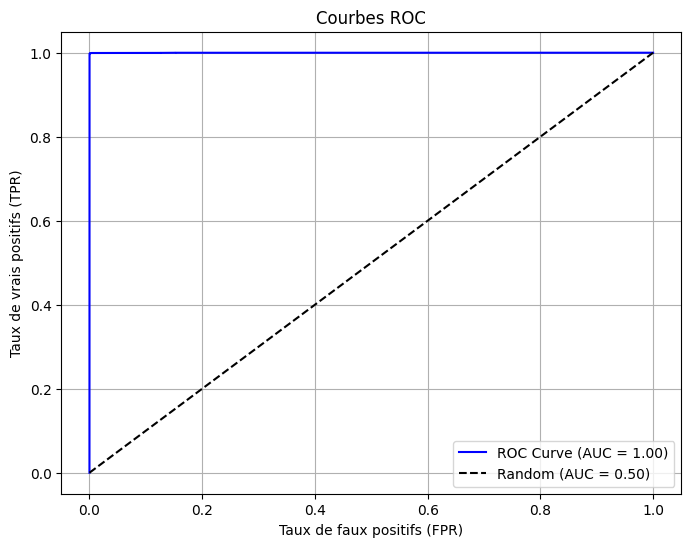

In [ ]:
# Preparation des données
X_ml = concatenated_data.drop(['label_dl', 'label_ml'], axis=1)
y_ml = concatenated_data['label_ml']

scaler = StandardScaler()
X_ml = scaler.fit_transform(X_ml)

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# Définir le modèle Random Forest et l’espace des hyperparamètres optimisé
rf_model = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': np.arange(50, 150, 50),
    'max_depth': np.arange(5, 10, 5),
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'criterion': ['gini'],
    'class_weight': ['balanced']
}

# Définir un score personnalisé (pour limiter les faux positifs)
def custom_scorer(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (tp - fp) / (tp + fp + 1e-6)

# Application de la Optimized Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring=make_scorer(custom_scorer),
    cv=2,
    random_state=42,
    n_jobs=-1
)

# Entraîner le modèle avec les meilleurs paramètres
random_search.fit(X_train_ml, y_train_ml)

# Afficher les meilleurs paramètres et entraîner le modèle final
print("Best Parameters (Random Search):", random_search.best_params_)
print("Best Score (Random Search):", random_search.best_score_)

best_rf_model = random_search.best_estimator_

# Évaluer le modèle Random Forest final
y_pred_rf = best_rf_model.predict(X_test_ml)

print("Random Forest Performance (Optimized Model):")
print(classification_report(y_test_ml, y_pred_rf))
notation(X_test_ml, y_test_ml, y_pred_rf, best_rf_model)

# Enregistrer les prédictions dans le jeu de données
concatenated_data["predict_ml"] = best_rf_model.predict(X_ml)


## Phase 2: CNN

### Entrainement du CNN

In [ ]:
# Filtrer les données pour garder que les prédit comme attaque
data_dl = concatenated_data[concatenated_data["label_ml"] != 0]

# Séparation des Features & Labels
X_dl = data_dl.drop(['label_dl', 'label_ml', 'predict_ml'], axis=1)
y_dl = data_dl['label_dl']

# Encoder les Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_dl)

# Normaliser les Features
scaler = StandardScaler()
X_dl = scaler.fit_transform(X_dl)

# Vérification de la distrubution des calsses avant l'équilibrage
initial_counts = Counter(y_encoded)
print(f"Distribution initiale des labels: {initial_counts}")

# Définition de la stratégie de l'équilibrage.
majority_class = max(initial_counts, key=initial_counts.get)
target_size = int(initial_counts[majority_class] * 0.5)  # Reduce the majority class to 50%

# SMOTE pour le suréchantillonnage des classes minoritaires
smote_strategy = {k: max(v, target_size) for k, v in initial_counts.items() if v < target_size}

# Sous-échantillonnage de la classe majoritaire
under_strategy = {majority_class: target_size}

# Appliquer le rééchantillonnage (SMOTE + sous-échantillonnage)
resampling_pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=smote_strategy, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy=under_strategy, random_state=42))
])

X_resampled, y_resampled = resampling_pipeline.fit_resample(X_dl, y_encoded)

# Vérifier la distribution des classes après rééchantillonnage
print(f"Nouvelle distribution des labels: {Counter(y_resampled)}")

# Convertir les labels en format catégoriel (One-Hot Encoding)
y_categorical = to_categorical(y_resampled)

# Diviser les données en ensembles d'entraînement et de test
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_resampled, y_categorical, test_size=0.2, random_state=42)

# Redimensionner les données pour le CNN
X_train_dl = np.expand_dims(X_train_dl, axis=2)
X_test_dl = np.expand_dims(X_test_dl, axis=2)

# Définition du modèle CNN
model_dl = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_dl.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(filters=32, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_categorical.shape[1], activation='softmax')  # Multi-class classification
])

# Compiler le modèle
model_dl.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

# Entrainement du modèle
history = model_dl.fit(X_train_dl, y_train_dl, epochs=10, batch_size=32, validation_split=0.2)

# Evaluation du modèle.
loss, accuracy = model_dl.evaluate(X_test_dl, y_test_dl)
print(f"Final CNN Accuracy: {accuracy:.4f}")


Distribution initiale des labels: Counter({np.int64(3): 200291, np.int64(0): 3404, np.int64(1): 180, np.int64(2): 175, np.int64(4): 62, np.int64(5): 49, np.int64(6): 35})
Nouvelle distribution des labels: Counter({np.int64(0): 100145, np.int64(1): 100145, np.int64(2): 100145, np.int64(3): 100145, np.int64(4): 100145, np.int64(5): 100145, np.int64(6): 100145})


c:\Users\ibrah\Desktop\IDIA-5A\PRED\PRED\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 111s 8ms/step - accuracy: 0.6662 - loss: 0.8487 - val_accuracy: 0.7686 - val_loss: 0.5942
Epoch 2/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 113s 8ms/step - accuracy: 0.7528 - loss: 0.6205 - val_accuracy: 0.7810 - val_loss: 0.5510
Epoch 3/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 112s 8ms/step - accuracy: 0.7700 - loss: 0.5836 - val_accuracy: 0.7928 - val_loss: 0.5195
Epoch 4/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 111s 8ms/step - accuracy: 0.7814 - loss: 0.5576 - val_accuracy: 0.8197 - val_loss: 0.4949
Epoch 5/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 116s 8ms/step - accuracy: 0.7943 - loss: 0.5324 - val_accuracy: 0.8260 - val_loss: 0.4895
Epoch 6/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 129s 9ms/step - accuracy: 0.7978 - loss: 0.5259 - val_accuracy: 0.8106 - val_loss: 0.4619
Epoch 7/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 109s 8ms/step - accuracy: 0.8024 - loss: 0.5144 - val_accuracy: 0.8330 - val_loss: 0.4536
Epoch 8/10
14021/14021 ━━━━━━━━━━━━━━━━━━━━ 111s 8ms/step - ac

In [14]:
# Extraction des Labels & Features pour le CNN
col_lab = data_dl[['label_dl', 'label_ml', 'predict_ml']]
data_final = data_dl.drop(['label_dl', 'label_ml', 'predict_ml'], axis=1)

# Normaliser les données avec le même scaler
data_final = scaler.transform(data_final)

# Redimensionner les données pour l'entrée du CNN
data_final = np.expand_dims(data_final, axis=2)

# Application du CNN pour la classification du type d'attaque
y_pred_dl = model_dl.predict(data_final)

# Convertir les prédictions en Label de classe
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_dl, axis=1))

# Reconstruire le DataFrame avec les prédictions du CNN
features = [col for col in concatenated_data.columns if col not in ['label_dl', 'label_ml', 'predict_ml']]
data_final = pd.DataFrame(data_final[:, :, 0], columns=features)  # Convert back to DataFrame
data_final['predict_dl'] = y_pred_labels  # Add CNN predictions
data_final['label_dl'] = data_dl['label_dl'].values  # Restore true attack labels

# Calculer les métriques de performance du modèle
y_test = data_final["label_dl"]
y_pred = data_final["predict_dl"]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

# Afficher les résultats
print(f"Final CNN Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print("Confusion Matrix:")
print(conf_matrix)


6379/6379 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step


c:\Users\ibrah\Desktop\IDIA-5A\PRED\PRED\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Final CNN Model Performance:
Accuracy: 0.9945
Precision: 0.9973
Confusion Matrix:
[[     0      0      0      0    101      0      0      0]
 [     0   2485    280    178      3    105     56    297]
 [     0      1    168      0      1      4      0      6]
 [     0      3      6    137      0     18      1     10]
 [     0      4      0      5 200113      0      0      0]
 [     0      1      5      3      0     43      0     10]
 [     0      0      3      1      0      6     36      3]
 [     0      0      2      2      0      4      1     26]]
